In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle

from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [2]:
def ODE_system_solver(f, y0, t0, final_t, step = 1e-4):

    ts = np.arange(t0, final_t, step)
    ys = np.empty((len(ts), len(y0)), dtype=np.float32)
    ys[0] = y0

    for i, t in enumerate(ts[:-1]):
        ys[i + 1] = ys[i] + f(t, ys[i]) * step

    return ts, ys

In [3]:
L = 1.0
Nx = 100
dx = L / Nx
phi = 0.2
u = 1e-6
mu_w = 1e-3
mu_g = 1e-5
S_wc = 0.2
S_gr = 0.1

S_inicial = 0.2
S_left = 0.9

In [4]:
# @nb.njit
def S_n(S):
    return (S - S_wc) / (1 - S_wc - S_gr)

# @nb.njit
def k_rw(S):
    return ((S - S_wc) / (1 - S_wc - S_gr)) ** 4

# @nb.njit
def k_rg(S):
    return ((1 - S - S_gr) / (1 - S_wc - S_gr)) ** 2

# @nb.njit
def f_w(S):
    lambda_w = k_rw(S) / mu_w
    lambda_g = k_rg(S) / mu_g
    return lambda_w / (lambda_w + lambda_g)

# @nb.njit
def f(S):
    return f_w(S) * u

# @nb.njit
def rhs(t, y):
    F = np.empty(y.shape[0] + 1, dtype=np.float32)
    F[0] = f(S_left)
    F[1:] = f(y)

    return -(F[1:] - F[:-1]) / (phi * dx)
    

In [5]:
xs = np.linspace(0, L, Nx)
S0 = np.full(xs.shape[0], S_inicial)
dt = 150.0
T_max = 150000

ts, us = ODE_system_solver(rhs, S0, 0, T_max, dt)
Nt = len(ts)

In [6]:
N_plot = 5000

idxs_t = np.random.randint(low=0, high=us.shape[0], size=N_plot)
idxs_x = np.random.randint(low=0, high=us.shape[1], size=N_plot)

X_plot = np.stack((ts[idxs_t], xs[idxs_x]), axis=1)
u_plot = us[idxs_t, idxs_x]

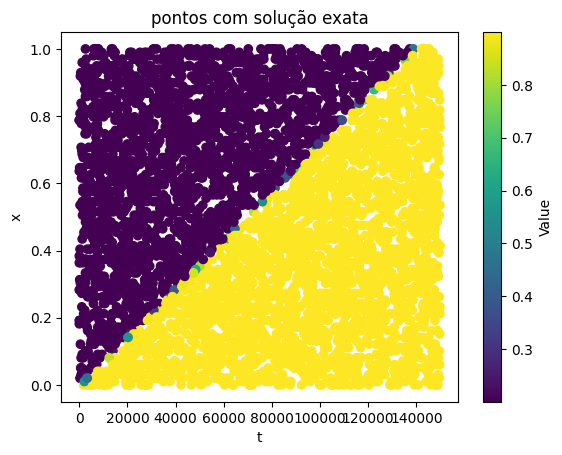

In [7]:
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=u_plot, cmap="viridis", vmin=us.min(), vmax=us.max())
plt.xlabel('t')
plt.ylabel('x')
plt.title('pontos com solução exata')
plt.colorbar(label='Value')
plt.show()

In [8]:
def f_prime(S):
    S = S.clone().detach().requires_grad_(True)
    f_val = f(S)

    return torch.autograd.grad(outputs=f_val, inputs=S, grad_outputs=torch.ones_like(f_val))[0].detach().numpy()

In [9]:
def pinn_loss(X_batch, y_fake, X_contorno, y_contorno, X_inicial, y_inicial, lambda_1 = 0.1, make_reduction=True):
    
    dy_dX = torch.autograd.grad(y_fake, X_batch, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    
    f_val = f(y_fake)
    df_dy = torch.autograd.grad(f_val, y_fake, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    
    dy_dt = dy_dX[:, :1]
    dy_dx = dy_dX[:, 1:]
    df_dx = df_dy * dy_dx # regra da cadeia

    if make_reduction:
        L_f = torch.mean((phi * dy_dt + df_dx) ** 2)
        L_b1 = torch.mean((y_inicial - 0.2) ** 2)
        L_b2 = torch.mean((y_contorno - 0.9) ** 2)
    
        return L_f + lambda_1 * (L_b1 + L_b2)
    else:
        L_f = (phi * dy_dt + df_dx) ** 2
        L_b1 = (y_inicial - 0.2) ** 2
        L_b2 = (y_contorno - 0.9) ** 2

        return L_f, L_b1, L_b2

In [10]:
def sample_points(N_colocacao, N_contorno, N_inicial):
    X_colocacao = torch.cat([
        (1 - torch.rand(N_colocacao, 1)) * T_max,
        torch.rand(N_colocacao, 1)
    ], dim = 1)

    X_contorno = torch.cat([
        (1 - torch.rand(N_contorno, 1)) * T_max, 
        torch.zeros(N_contorno, 1)
    ], dim = 1)

    X_inicial = torch.cat([
        torch.zeros(N_inicial, 1),
        torch.rand(N_inicial, 1)
    ], dim = 1)

    return X_colocacao, X_contorno, X_inicial

In [11]:
def replace_least_error_points(points, new_points, errors):

    N_todos = points.shape[0]
    N_novos = new_points.shape[0]
    N_resto = N_todos - N_novos
    
    idxs = np.argpartition(-errors.detach().numpy(), N_resto, axis=0).flatten()
    idxs = idxs[:N_resto]

    return torch.cat((points[idxs], new_points), axis=0)    

In [12]:
def resample_ozanski(X_colocacao, X_contorno, X_inicial, model, perc=0.15, perc_boundary=0.1, lambda_1=0.1):

    X_todos = torch.cat((X_contorno, X_inicial, X_colocacao), dim=0).requires_grad_(True)
    
    N_colocacao = X_colocacao.shape[0]
    N_contorno = X_contorno.shape[0]
    N_inicial = X_inicial.shape[0]

    y_fake = model(X_todos)
    y_fake_contorno = y_fake[0:N_contorno, :]
    y_fake_inicial = y_fake[N_contorno:N_contorno + N_inicial, :]

    L_f, L_b1, L_b2 = pinn_loss(X_todos, y_fake, X_contorno, y_fake_contorno, X_inicial, y_fake_inicial, make_reduction=False)

    loss_contorno = L_f[0:N_contorno, :] + lambda_1 * L_b2
    loss_inicial = L_f[N_contorno:N_contorno + N_inicial, :] + lambda_1 * L_b1
    loss_colocacao = L_f[N_contorno + N_inicial:, :]

    X_novos_colocacao, X_novos_contorno, X_novos_inicial = sample_points(int(N_colocacao * perc), int(N_contorno * perc_boundary), int(N_inicial * perc_boundary))

    X_final_colocacao = replace_least_error_points(X_colocacao, X_novos_colocacao, loss_colocacao)
    X_final_contorno = replace_least_error_points(X_contorno, X_novos_contorno, loss_contorno)
    X_final_inicial = replace_least_error_points(X_inicial, X_novos_inicial, loss_inicial)

    return X_final_colocacao, X_final_contorno, X_final_inicial

In [13]:
# _, X_contorno, X_inicial = resample_ozanski(X_colocacao, X_contorno, X_inicial, PINN_model)

In [14]:
class PINN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, z):
        scale = torch.tensor([T_max, 1.0])
        z_normalized = z / scale
        return self.net(z_normalized)

In [15]:
N_colocacao = 3000
N_contorno = 500
N_inicial = 500

X_colocacao, X_contorno, X_inicial = sample_points(N_colocacao, N_contorno, N_inicial)

In [16]:
n_iter = 50000

batch_size = 256
batch_contorno = batch_size // 10
batch_inicial = batch_size // 10
batch_colocacao = batch_size - batch_contorno - batch_inicial

PINN_model = PINN(2, 1, 32)

lr = 1e-3
optimizer = optim.Adam(PINN_model.parameters(), lr=lr)


N_change_points = 75
N_min_discontinuity = n_iter - 20000
N_change_discontinuity = 75
N_verify_discontinuity = 5

In [17]:
# PREPARE CLINN STUFF

In [18]:
def discontinuity_indicator(points, model):
    
    W, M, C = 10.0, -12.0, -1.0

    with torch.no_grad():
        approx_Us = model(points).squeeze()
    lam = f_prime(approx_Us) / u

    # 0.5 since our points are equally spaced
    lam_L = 0.5 * (lam[:, :-2] + lam[:, 1:-1])
    lam_R = 0.5 * (lam[:, 1:-1] + lam[:, 2:])

    # skipped the sigmoid because it isn't really necessary
    out = W * (lam_L - lam_R) + M * dx + C
    
    indicator = np.zeros((Nt, Nx), dtype=np.bool)

    # in the paper, they proposed to use sigmoid(out) > 0.5 <=> out > 0
    # I found that to be too little, and it would give too many false positives
    indicator[:, 1:-1] = out > 30

    return indicator

In [19]:
# estimate the normal vectors of a surface from a cloud of points that are (approximately) in the surface
def estimate_normals(points, k):

    N, d = points.shape
    if (N < k * 2):
        return np.zeros((N, d))

    KNN = NearestNeighbors(n_neighbors=k)
    scaled_points = points / torch.tensor([15000, 1])
    KNN.fit(scaled_points)
    _, indices = KNN.kneighbors(scaled_points)

    normals = np.zeros((N, d))

    for i in range(N):
        neighborhood = points[indices[i]]
        neighborhood -= neighborhood.mean(axis=0)

        pca = PCA(n_components=d)
        pca.fit(neighborhood)

        # the PC with smallest eigenvalue will approximate the normal
        normals[i] = pca.components_[-1] # problem: when should it return -pca.components_[-1]??

    return normals

In [20]:
def get_normal_and_velocity(discontinuous_points):

    N, d = discontinuous_points.shape
    if (N < 50):
        return torch.zeros((N, 1)), torch.zeros((N, d - 1))
    
    normals = estimate_normals(discontinuous_points, 20)
    partial_t = normals[:, :1]
    grad_x = normals[:, 1:]
    grad_x_norm = np.linalg.norm(grad_x, axis=1).reshape(-1, 1)

    if (np.any(grad_x_norm == 0)):
        odashfoisudgf

    return torch.tensor(grad_x / grad_x_norm), torch.tensor(-partial_t / grad_x_norm)

In [21]:
# points in a Nx x Nt grid
all_points = torch.tensor(np.stack(np.meshgrid(ts, xs, indexing="ij"), -1), dtype=torch.float32)

discontinuity_mask = discontinuity_indicator(all_points, PINN_model)
discontinuous_points = all_points[discontinuity_mask]
normals, velocities = get_normal_and_velocity(discontinuous_points)

In [22]:
np.sum(discontinuity_mask)

np.int64(0)

In [23]:
def calculate_Rankine_Hugoniot_loss(model):

    if (not np.any(discontinuity_mask)):
        return 0
    
    points_L = all_points.roll(1, dims=0)[discontinuity_mask]
    points_R = all_points.roll(-1, dims=0)[discontinuity_mask]
    u_L = model(points_L)
    u_R = model(points_R)

    valid_points = u_L != u_R
    u_L = u_L[valid_points]
    u_R = u_R[valid_points]

    return torch.mean((normals[valid_points] * (f(u_L) - f(u_R)) / (u_L - u_R) - velocities[valid_points]).flatten() ** 2)    

In [24]:
def calculate_BD_loss(model, points):
    u = model(points)
    return torch.mean(torch.relu(u - S_left) ** 2 + torch.relu(S_inicial - u) ** 2)

In [25]:
# n_iter = 10000
# N_min_discontinuity = 0

In [26]:
for it in range(n_iter):

    X_batch_colocacao = X_colocacao[torch.randint(0, N_colocacao, (batch_colocacao,))]
    X_batch_contorno = X_contorno[torch.randint(0, N_contorno, (batch_contorno,))]
    X_batch_inicial = X_inicial[torch.randint(0, N_inicial, (batch_inicial,))]
    # X_batch_colocacao, X_batch_contorno, X_batch_inicial = sample_points(batch_colocacao, batch_contorno, batch_inicial)
    
    X_batch = torch.cat((X_batch_contorno, X_batch_inicial, X_batch_colocacao), dim=0).requires_grad_(True)
    
    y_fake = PINN_model(X_batch)
    y_fake_contorno = y_fake[0:batch_contorno, :]
    y_fake_inicial = y_fake[batch_contorno:batch_contorno + batch_inicial, :]
    
    L_PINN = pinn_loss(X_batch, y_fake, X_batch_contorno, y_fake_contorno, X_batch_inicial, y_fake_inicial)
    
    # if it >= N_min_discontinuity:
    if (it // 2000) % 2 == 1:

        if it % N_change_discontinuity == 0 or it == N_min_discontinuity:
            discontinuity_mask = discontinuity_indicator(all_points, PINN_model)
            discontinuous_points = all_points[discontinuity_mask]
            normals, velocities = get_normal_and_velocity(discontinuous_points)

        if it % N_verify_discontinuity == 0:
            new_mask = discontinuity_indicator(all_points, PINN_model)[discontinuity_mask]
            discontinuity_mask[discontinuity_mask] &= new_mask
            discontinuous_points = discontinuous_points[new_mask]
            normals = normals[new_mask]
            velocities = velocities[new_mask]

        L_CLINN = L_PINN + calculate_Rankine_Hugoniot_loss(PINN_model) * 10 + calculate_BD_loss(PINN_model, X_batch_colocacao) * 0.05
            
    else:
        L_CLINN = L_PINN + calculate_BD_loss(PINN_model, X_batch_colocacao) * 0.05
    
    optimizer.zero_grad()
    L_CLINN.backward()
    optimizer.step()
    

    if it % N_change_points == 0:
        X_colocacao, X_contorno, X_inicial = resample_ozanski(X_colocacao, X_contorno, X_inicial, PINN_model)
    
    if (it + 1) % (n_iter // 10) == 0:
        print(f"Iter {it+1}: L_PINN={L_PINN.item():.10f}, outro: {np.sum(discontinuity_indicator(all_points, PINN_model))}")

Iter 5000: L_PINN=0.0000392919, outro: 21
Iter 10000: L_PINN=0.0000156033, outro: 35
Iter 15000: L_PINN=0.0000005651, outro: 138
Iter 20000: L_PINN=0.0000005157, outro: 504
Iter 25000: L_PINN=0.0000008359, outro: 85
Iter 30000: L_PINN=0.0000073297, outro: 603
Iter 35000: L_PINN=0.0000000127, outro: 631
Iter 40000: L_PINN=0.0000015061, outro: 770
Iter 45000: L_PINN=0.0000861067, outro: 676
Iter 50000: L_PINN=0.0005049294, outro: 266


In [27]:
L_PINN

tensor(0.0005, grad_fn=<AddBackward0>)

In [28]:
discontinuity_mask = discontinuity_indicator(all_points, PINN_model)
discontinuous_points = all_points[discontinuity_mask]
normals, velocities = get_normal_and_velocity(discontinuous_points)

In [29]:
calculate_Rankine_Hugoniot_loss(PINN_model) * 1e5

tensor(1.7143e-05, dtype=torch.float64, grad_fn=<MulBackward0>)

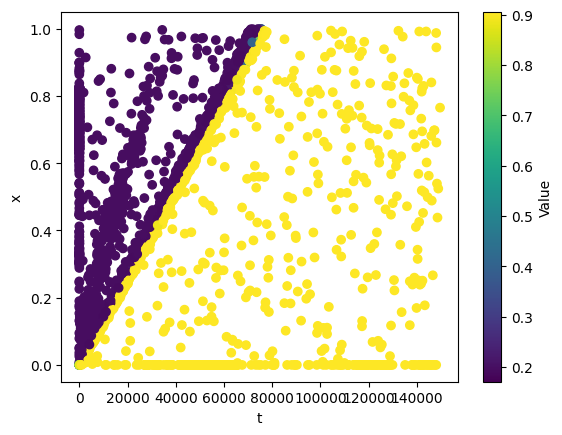

In [30]:
# X_colocacao, X_contorno, X_inicial = sample_points(3400, 300, 300)
x_plot = torch.cat((X_colocacao, X_inicial, X_contorno))
# x_plot = X_colocacao

y_pred = PINN_model(x_plot).detach().numpy()
x_plot = x_plot.detach().numpy()

plt.scatter(x_plot[:, 0], x_plot[:, 1:], c=y_pred, cmap="viridis")
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()

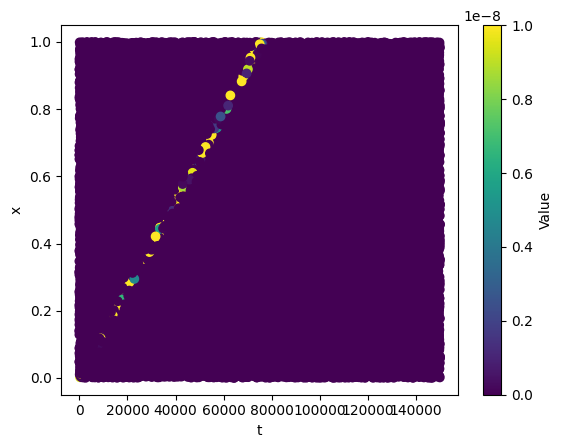

In [31]:
x_plot, *_ = sample_points(50000, 10000, 10000)
x_grad = x_plot.detach().clone().requires_grad_(True)
y_fake = PINN_model(x_grad)
L_f, *_ = pinn_loss(x_grad, y_fake, torch.empty(0, 2), torch.empty(0, 1), torch.empty(0, 2), torch.empty(0, 1), 0.0, False)

x_plot = x_plot.detach().numpy()
L_f = L_f.detach().numpy()

plt.scatter(x_plot[:, 0], x_plot[:, 1:], c=L_f, cmap="viridis", vmax=1e-8)
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()

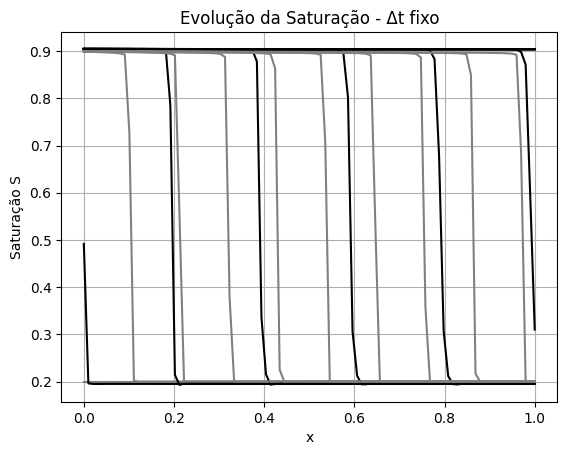

In [32]:
for idx, t in enumerate(ts[::100]):
    X = torch.tensor(np.stack([np.full(xs.shape, t), xs], axis=1), dtype=torch.float32)
    S = PINN_model(X).detach().cpu().numpy()

    # print(xs.shape, us[t].shape)
    plt.plot(xs, us[idx * 100, :], label=f't = {t/3600:.1f} h', color="gray")
    plt.plot(xs, S, label=f't = {t/3600:.1f} h', color="black")

plt.xlabel('x')
plt.ylabel('Saturação S')
plt.title('Evolução da Saturação - Δt fixo')
# plt.legend()
plt.grid(True)
plt.show()

In [33]:
with torch.no_grad():
    approx_Us = PINN_model(torch.tensor(np.stack(np.meshgrid(ts, xs, indexing="ij"), -1), dtype=torch.float32)).reshape(ts.size, xs.size)


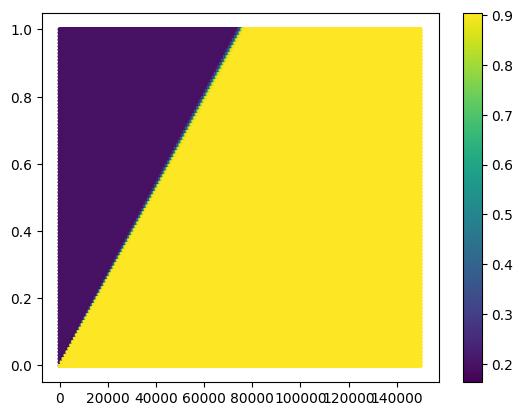

In [34]:
plt.scatter(*np.meshgrid(ts, xs, indexing="ij"),
            c=approx_Us.detach().cpu().numpy().ravel(),
            s=5)
plt.colorbar()
plt.show()

In [35]:
Nt, Nx = approx_Us.shape

# paper constants
W, M, C = 10.0, -12.0, -1.0

indicator = np.zeros((Nt, Nx), dtype=np.float32)

lam = f_prime(approx_Us) / u
lam_L = 0.5 * (lam[:, :-2] + lam[:, 1:-1])
lam_R = 0.5 * (lam[:, 1:-1] + lam[:, 2:])

out = W * (lam_L - lam_R) + M * dx + C

indicator[:, 1:-1] = out > 30

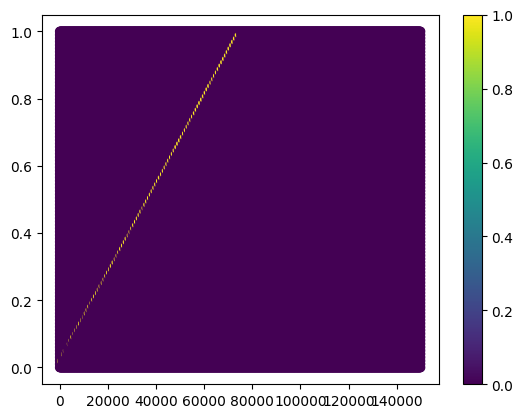

In [36]:
plt.scatter(*np.meshgrid(ts, xs, indexing="ij"),
            c=indicator.ravel())
plt.colorbar()
plt.show()

In [37]:
np.sum(indicator)

np.float32(266.0)